In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 2450000
from emcee.autocorr import integrated_time

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [3]:

mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [4]:
def weighted_percentile(data, weights, percentiles=[16, 50, 84]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]
    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]
    return np.interp(np.array(percentiles)/100, cumsum, data_sorted)

def calc_ln_prior_kep(theta, thS, vEarth):
    t0, u0, q, ML, DL, DS, murel_N_hel, murel_E_hel,orbital_radi, e, cos_i, Om_NE, om, nu = parametrics.lightcurve_to_physical_kepler(theta, thS, vEarth)

    mu_abs = jnp.sqrt(murel_E_hel**2 + murel_N_hel**2)
    mu_phi = jnp.arctan2(murel_E_hel, murel_N_hel)
    DL *= 1e3
    DS *= 1e3

    if not (10000 <= t0 <= 11000):
        return -np.inf
    if not (-5 <= u0 <= 5):
        return -np.inf
    if not (1e-5 <= q <= 1.0):
        return -np.inf
    if not (0 <= e <= 1.0):
        return -np.inf
    if not (-np.pi <= Om_NE <= np.pi):
        return -np.inf
    if not (-np.pi <= om <= np.pi):
        return -np.inf
    if not (-np.pi <= nu <= np.pi):
        return -np.inf
    if not (0 <= orbital_radi <= 1e4):
        return -np.inf

    if not (gapmoe_model.M_MIN <= ML <= gapmoe_model.M_MAX):
        return -np.inf
    if not (gapmoe_model.DL_MIN <= DL < gapmoe_model.DL_MAX):
        return -np.inf
    if not (gapmoe_model.DS_MIN <= DS < gapmoe_model.DS_MAX):
        return -np.inf
    if DL >= DS:
        return -np.inf
    if not (gapmoe_model.MU_MIN <= mu_abs < gapmoe_model.MU_MAX):
        return -np.inf

    return gapmoe_model.log_galactic_prior(ML, DL, DS, mu_abs, mu_phi) - np.log(mu_abs) #jacobian for (muN, muE) -> (mu,phi)

def calc_ln_prior_circ(theta, thS, vEarth):
    t0, u0, q, ML, DL, DS, murel_N_hel, murel_E_hel,orbital_radi, cos_i, Om_NE, phi0 = parametrics.lightcurve_to_physical_circular(theta, thS, vEarth)

    mu_abs = jnp.sqrt(murel_E_hel**2 + murel_N_hel**2)
    mu_phi = jnp.arctan2(murel_E_hel, murel_N_hel)
    DL *= 1e3
    DS *= 1e3

    if not (10000 <= t0 <= 11000):
        return -np.inf
    if not (-5 <= u0 <= 5):
        return -np.inf
    if not (1e-5 <= q <= 1.0):
        return -np.inf
    if not (-np.pi <= Om_NE <= np.pi):
        return -np.inf
    if not (-np.pi <= phi0 <= np.pi):
        return -np.inf
    if not (0 <= orbital_radi <= 1e4):
        return -np.inf

    if not (gapmoe_model.M_MIN <= ML <= gapmoe_model.M_MAX):
        return -np.inf
    if not (gapmoe_model.DL_MIN <= DL < gapmoe_model.DL_MAX):
        return -np.inf
    if not (gapmoe_model.DS_MIN <= DS < gapmoe_model.DS_MAX):
        return -np.inf
    if DL >= DS:
        return -np.inf
    if not (gapmoe_model.MU_MIN <= mu_abs < gapmoe_model.MU_MAX):
        return -np.inf

    return gapmoe_model.log_galactic_prior(ML, DL, DS, mu_abs, mu_phi) - np.log(mu_abs) #jacobian for (muN, muE) -> (mu,phi)

In [5]:
muN_correct  = 1.368574  # mas/yr
muE_correct   = 1.268582  # mas/yr
ML_correct      = 0.422433       # M_sun
DL_correct        = 6.687129       # kpc
DS_correct       = 8.118116       # kpc
R_orbit_correct   = 2.343343  # AU
e_correct    = 0.099897
cos_i_correct    = -0.098078
omega_correct    = 0.409890
Omega_correct    = -1.511892
nu_correct    = 1.512175

t0_correct = 10085 
u0_correct = 0.01 
q_correct = 0.001
alpha_correct = np.pi/2 + 1
tE_correct = 58.8441
rho_correct = 0.000597948
s_correct = 1.14543
piEN_correct = 0.0635109
piEE_correct = 0.0602449
gamma1_correct = 0.000316484
gamma2_correct = -0.000313964
gamma3_correct = 0.00318583
rs_correct = 0.000281588
as_correct = 1.01599

In [17]:
def read_chain(path,burnin,thin,flat=True):
    sampler = emcee.backends.HDFBackend(path)
    chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
    lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin)
    blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin) 
    
    return chain, lnprob, blob

def read_chain_tmp(path,burnin,thin,flat=True):
    sampler = emcee.backends.HDFBackend(path)
    chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
    
    return chain


def cut_chain_lnprobs(chain,lnprob,blob,th):
    ind = np.where(lnprob>th)[0]
    return chain[ind], lnprob[ind], blob[ind]

def cut_chain_x(chain,lnprob,blob, bound,label_inds):
    mask = np.ones(chain.shape[0], dtype=bool)
    for key, (low, high) in bound.items():
        idx = label_inds[key]
        mask &= (chain[:, idx] >= low) & (chain[:, idx] <= high)

    return chain[mask], lnprob[mask], blob[mask]

def cut_chain_y(chain,bound,label_inds,lndet=None,lngal=None):
    mask = np.ones(chain.shape[0], dtype=bool)
    for key, (low, high) in bound.items():
        idx = label_inds[key]
        mask &= (chain[:, idx] >= low) & (chain[:, idx] <= high)

    if lndet is None:
        return chain[mask]
    else:
        return chain[mask], lndet[mask],lngal[mask]

In [7]:
kep_gap_chain, kep_gap_lnprob, kep_gap_thS= read_chain("../backup_important/rerun_simu_01_kepler_chain_01.h5",1000,2000,flat=True)
kep_wo_chain, kep_wo_lnprob, kep_wo_thS= read_chain("../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5",1000,2000,flat=True)
circ_gap_chain, circ_gap_lnprob, circ_gap_thS= read_chain("../backup_important/rerun_simu_01_circular_chain_01.h5",1000,2000,flat=True)
circ_wo_chain, circ_wo_lnprob, circ_wo_thS= read_chain("../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5",1000,2000,flat=True)

In [8]:
kep_gap_chain_nf, kep_gap_lnprob_nf, kep_gap_thS_nf = read_chain(
    "../backup_important/rerun_simu_01_kepler_chain_01.h5", 1000, 100, flat=False)

kep_wo_chain_nf, kep_wo_lnprob_nf, kep_wo_thS_nf = read_chain(
    "../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5", 1000, 100, flat=False)

circ_gap_chain_nf, circ_gap_lnprob_nf, circ_gap_thS_nf = read_chain(
    "../backup_important/rerun_simu_01_circular_chain_01.h5", 1000, 100, flat=False)

circ_wo_chain_nf, circ_wo_lnprob_nf, circ_wo_thS_nf = read_chain(
    "../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5", 1000, 100, flat=False)

KeyboardInterrupt: 

In [ ]:
circ_gap_chain, circ_gap_lnprob, circ_gap_thS = cut_chain_lnprobs(circ_gap_chain, circ_gap_lnprob, circ_gap_thS,th=-8775)
circ_wo_chain, circ_wo_lnprob, circ_wo_thS = cut_chain_lnprobs(circ_wo_chain, circ_wo_lnprob, circ_wo_thS,th=-8800)

In [7]:
label_inds_kep = {
    "t0": 0,
    "tE": 1,
    "u0": 2,
    "rho": 3,
    "q": 4,
    "s": 5,
    "alpha": 6,
    "piEN": 7,
    "piEE": 8,
    "gamma1": 9,
    "gamma2": 10,
    "gamma3": 11,
    "rs": 12,
    "as": 13,
}

label_inds_circ = {
    "t0": 0,
    "tE": 1,
    "u0": 2,
    "rho": 3,
    "q": 4,
    "s": 5,
    "alpha": 6,
    "piEN": 7,
    "piEE": 8,
    "gamma1": 9,
    "gamma2": 10,
    "gamma3": 11,
}

In [ ]:
bound_kep_x = {"rs": [-8, 8],"as":[0,6]}

In [ ]:
kep_gap_chain, kep_gap_lnprob, kep_gap_thS = cut_chain_x(
    kep_gap_chain, kep_gap_lnprob, kep_gap_thS, bound_kep_x,label_inds_kep)

In [ ]:
corner.corner(kep_gap_chain,labels=list(label_inds_kep.keys()))
plt.show()

In [ ]:
corner.corner(kep_wo_chain,labels=list(label_inds_kep.keys()))
plt.show()

In [ ]:
corner.corner(circ_gap_chain,labels=list(label_inds_circ.keys()))
plt.show()

In [ ]:
corner.corner(circ_wo_chain,labels=list(label_inds_circ.keys()))
plt.show()

In [ ]:
vmap_kep = jax.vmap(
    lambda theta, thS: parametrics.lightcurve_to_physical_kepler(theta, thS, vEarth),
    in_axes=(0, 0)
)

vmap_circ = jax.vmap(
    lambda theta, thS: parametrics.lightcurve_to_physical_circular(theta, thS, vEarth),
    in_axes=(0, 0)
)

vmap_det_kep = jax.vmap(
    lambda theta, thS: parametrics.calc_ln_det_jacobian_kepler(theta, thS, vEarth),
    in_axes=(0, 0)
)

vmap_det_circ = jax.vmap(
    lambda theta, thS: parametrics.calc_ln_det_jacobian_circular(theta, thS, vEarth),
    in_axes=(0, 0)
)

kep_gap_phys = np.array(vmap_kep(kep_gap_chain, kep_gap_thS))
kep_wo_phys = np.array(vmap_kep(kep_wo_chain, kep_wo_thS))
kep_wo_det = np.array(vmap_det_kep(kep_wo_chain, kep_wo_thS))
kep_wo_gal = np.array(list(map(
    lambda args: calc_ln_prior_kep(args[0], args[1], vEarth),
    zip(kep_wo_chain, kep_wo_thS)
)))

circ_gap_phys = np.array(vmap_circ(circ_gap_chain, circ_gap_thS))
circ_wo_phys = np.array(vmap_circ(circ_wo_chain, circ_wo_thS))
circ_wo_det = np.array(vmap_det_circ(circ_wo_chain, circ_wo_thS))
circ_wo_gal = np.array(list(map(
    lambda args: calc_ln_prior_circ(args[0], args[1], vEarth),
    zip(circ_wo_chain, circ_wo_thS)
)))

In [8]:
label_inds_kep_phys = {
    "ML":3,
    "DL": 4,
    "DS": 5,
    "muN": 6,
    "muE": 7,
    "a": 8,
    "e": 9,
    "cos_i": 10,
    "Omega": 11,
    "omega":12,
    "nu":13,
}

label_inds_kep_phys_log = {
    "log ML":3,
    "log DL": 4,
    "log DS": 5,
    "muN": 6,
    "muE": 7,
    "a": 8,
    "e": 9,
    "cos_i": 10,
    "Omega": 11,
    "omega":12,
    "nu":13,
}

label_inds_circ_phys = {
    "ML":3,
    "DL": 4,
    "DS": 5,
    "muN": 6,
    "muE": 7,
    "a": 8,
    "cos_i": 9,
    "Omega":10,
    "phi0": 11
}

label_inds_circ_phys_log = {
    "log ML":3,
    "log DL": 4,
    "log DS": 5,
    "muN": 6,
    "muE": 7,
    "a": 8,
    "cos_i": 9,
    "Omega":10,
    "phi0": 11
}

truths_kep = [
    ML_correct,
    DL_correct,
    DS_correct,
    muN_correct,
    muE_correct,
    R_orbit_correct,
    e_correct,
    cos_i_correct,
    omega_correct,
    Omega_correct,
    nu_correct
]

truths_circ_x = [
    t0_correct,
    tE_correct,
    u0_correct,
    rho_correct,
    q_correct,
    s_correct,
    alpha_correct,
    piEN_correct,
    piEE_correct,
    gamma1_correct,
    gamma2_correct,
    gamma3_correct,
]

truths_circ = parametrics.lightcurve_to_physical_circular(jnp.array(truths_circ_x),0.0001800539,vEarth)[3:]


# truths_circ = [
#     ML_correct,
#     DL_correct,
#     DS_correct,
#     muN_correct,
#     muE_correct,
#     R_orbit_correct,
#     cos_i_correct,
#     Omega_correct,
#     omega_correct+ nu_correct
# ]

truths_kep_log = [
    np.log10(ML_correct),
    np.log10(DL_correct),
    np.log10(DS_correct),
    muN_correct,
    muE_correct,
    R_orbit_correct,
    e_correct,
    cos_i_correct,
    omega_correct,
    Omega_correct,
    nu_correct
]

truths_circ_log = [
    np.log10(ML_correct),
    np.log10(DL_correct),
    np.log10(DS_correct),
    muN_correct,
    muE_correct,
    R_orbit_correct,
    cos_i_correct,
    Omega_correct,
    omega_correct+ nu_correct
]

In [ ]:
parametrics.lightcurve_to_physical_circular(jnp.array(truths_circ_x),0.0001800539,vEarth)[3:]

In [ ]:
bound_kep_y = {"a": [0,15]}

kep_gap_phys = cut_chain_y(kep_gap_phys,bound_kep_y ,label_inds_kep_phys)
kep_wo_phys, kep_wo_det, kep_wo_gal = cut_chain_y(kep_wo_phys,bound_kep_y ,label_inds_kep_phys,lndet=kep_wo_det,lngal=kep_wo_gal)

In [ ]:
corner.corner(kep_gap_phys[:,3:],labels=list(label_inds_kep_phys),truths=truths_kep)

plt.show()

In [ ]:
weight_kep = np.exp((kep_wo_det + kep_wo_gal) - np.max(kep_wo_det + kep_wo_gal))
weight_kep /= np.sum(weight_kep)

corner.corner(kep_wo_phys[:,3:],labels=list(label_inds_kep_phys),truths=truths_kep,weights=weight_kep)

plt.show()

In [ ]:
corner.corner(circ_gap_phys[:,3:],labels=list(label_inds_circ_phys),truths=truths_circ)

plt.show()

In [ ]:
weight_circ = np.exp((circ_wo_det + circ_wo_gal)-np.max(circ_wo_det + circ_wo_gal))
weight_circ /= np.sum(weight_circ)

corner.corner(circ_wo_phys[:,3:],labels=list(label_inds_circ_phys),truths=truths_circ,weights=weight_circ)

plt.show()

In [ ]:
def make_log_scale(physical_params):
    for name in ["ML","DL","DS"]:
        ind = label_inds_kep_phys[name]
        physical_params[:,ind] = np.log10(physical_params[:,ind])
    return physical_params        

In [ ]:
kep_gap_phys_log = make_log_scale(kep_gap_phys.copy())
kep_wo_phys_log = make_log_scale(kep_wo_phys.copy())

circ_gap_phys_log = make_log_scale(circ_gap_phys.copy())
circ_wo_phys_log = make_log_scale(circ_wo_phys.copy())

In [ ]:
ranges = [
    (-1.5, 0.7),       # logML
    (0.6, 1.2),        # logDL
    (0.6, 1.2),        # logDS
    (-3, 3),           # mu_rel_N
    (-3, 3)            # mu_rel_E
]

fig = corner.corner(
    kep_gap_phys_log[:, 3:8],
    labels=list(label_inds_kep_phys_log)[:5],
    truths=truths_kep_log[:5],
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0/2,
    range=ranges
)

corner.corner(
    kep_wo_phys_log[:, 3:8],
    fig=fig,
    weights=weight_kep,
    color="C3",
    truths=truths_kep_log[:5],
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
    contour_kwargs={"zorder": 6, "linewidths": 3, "alpha": 1},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=.5,
    range=ranges
)

ndim = kep_gap_phys_log[:, 3:8].shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)

truths = truths_kep_log[:5]
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", markersize=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

    ax.set_ylim(bottom=0)
    ymax = 0
    for line in ax.lines:
        if line.get_linestyle() != '--':
            ydata = line.get_ydata()
            if ydata is not None and len(ydata) > 0:
                ymax = max(ymax, max(ydata))
    if ymax > 0:
        ax.set_ylim(top=ymax * 1.1)

legend_handles = [
    Line2D([0], [0], color="C0", lw=3, label="Kepler Model"),
    Line2D([0], [0], color="C3", lw=3, alpha=0.8, label="Kepler Model (Weighted, No Gap)")
]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=14,
    frameon=False,
    borderpad=1,
    labelspacing=0.6
)

plt.show()

In [ ]:
ranges = [
    (-1.5, 0.7),       # logML
    (0.6, 1.2),      # logDL
    (0.6, 1.2),      # logDS
    (-3, 3),         # mu_rel_N
    (-3, 3)        # mu_rel_E
]

# --- Base: Kepler model (blue) ---
fig = corner.corner(
    circ_gap_phys_log[:, 3:8],
    labels=list(label_inds_kep_phys_log)[:5],
    truths=truths_kep_log[:5],
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0/2,
)

# --- Without gap (red, weighted) ---
corner.corner(
    circ_wo_phys_log[:, 3:8],
    fig=fig,
    weights=weight_circ,
    color="C3",
    truths=truths_kep_log[:5],
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
    contour_kwargs={"zorder": 6, "linewidths": 3, "alpha": 1},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0/2,
)

# --- 軸補助設定 (見やすくする) ---
ndim = kep_gap_phys_log[:, 3:8].shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)

# --- truths の線を引く ---
truths = truths_kep_log[:5]
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", markersize=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

    # ヒストグラムのY軸を調整
    ax.set_ylim(bottom=0)
    ymax = 0
    for line in ax.lines:
        if line.get_linestyle() != '--':
            ydata = line.get_ydata()
            if ydata is not None and len(ydata) > 0:
                ymax = max(ymax, max(ydata))
    if ymax > 0:
        ax.set_ylim(top=ymax * 1.1)

# --- Legend を追加 ---
legend_handles = [
    Line2D([0], [0], color="C0", lw=3, label="Circular Model"),
    Line2D([0], [0], color="C3", lw=3, alpha=0.8, label="Circular Model (Weighted, No Gap)")
]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=14,
    frameon=False,
    borderpad=1,
    labelspacing=0.6
)


plt.show()


In [ ]:
def check_ess(path, weights=None):
    chain, lnprob, blob = read_chain(path, 1000, 1, flat=False)
    n_steps, n_walkers, n_dim = chain.shape

    label_tmp = list(label_inds_kep.keys())
    ess = []
    for d in range(n_dim):
        taus = [integrated_time(chain[:, w, d], quiet=True)[0]
                for w in range(n_walkers)]
        tau_mean = np.mean(taus)
        N_eff = n_steps * n_walkers / tau_mean
        ess.append(N_eff)
        print(f"{label_tmp[d]}: tau={tau_mean:.1f}, ESS={N_eff:.0f}")

    if weights is not None:
        w = np.array(weights)
        w_norm = w / np.sum(w)
        ess_weighted = 1.0 / np.sum(w_norm**2)
        print(f"\nReweighted ESS (全体): {ess_weighted:.0f}")
    print("\n")
    
def check_combined_ess(path, weights=None):
    chain, _, _ = read_chain(path, 1000, 1, flat=False)
    n_steps, n_walkers, n_dim = chain.shape
    N = n_steps * n_walkers

    tau_list = []
    for d in range(n_dim):
        taus = [integrated_time(chain[:, w, d], quiet=True)[0]
                for w in range(n_walkers)]
        tau_list.append(np.mean(taus))
    tau_max = np.max(tau_list)
    N_eff_mcmc = N / tau_max
    print(f"MCMC ESS: {N_eff_mcmc:.0f}")

    if weights is not None:
        w = np.array(weights)
        N_eff_weight = (np.sum(w)**2) / np.sum(w**2)
        print(f"Weighted ESS: {N_eff_weight:.5f}")

        N_eff_total = N_eff_mcmc * (N_eff_weight / N)
        print(f"Combined ESS: {N_eff_total:.5f}")
    print("\n")


In [ ]:
# print("kepler with gap")
# check_ess("../test_result/copy/rerun_simu_01_kepler_chain_01.h5")
# print("kepler without gap")
# check_ess("../test_result/copy/rerun_wo_gap_simu_01_kepler_chain_01.h5",weight_kep)
# print("circular with gap")
# check_ess("../test_result/copy/rerun_simu_01_circular_chain_01.h5")
# print("circular without gap")
# check_ess("../test_result/copy/rerun_wo_gap_simu_01_circular_chain_01.h5",weight_circ)

In [ ]:
# print("kepler with gap")
# check_combined_ess("../test_result/copy/rerun_simu_01_kepler_chain_01.h5")
# print("kepler without gap")
# check_combined_ess("../test_result/copy/rerun_wo_gap_simu_01_kepler_chain_01.h5",weight_kep)
# print("circular with gap")
# check_combined_ess("../test_result/copy/rerun_simu_01_circular_chain_01.h5")
# print("circular without gap")
# check_combined_ess("../test_result/copy/rerun_wo_gap_simu_01_circular_chain_01.h5",weight_circ)

In [19]:
def compare_tau_param(paths, labels, param_idx, burnin=1000, step_interval=500, c=50, ln_prob_th_list=None):
    """
    ln_prob_th_list: チェーンごとの閾値リスト（pathsと同じ長さ）
                     None の場合はカットなし
    """
    label_tmp = list(label_inds_kep.keys())
    pname = label_tmp[param_idx] if param_idx < len(label_tmp) else f"param {param_idx}"

    plt.figure(figsize=(6,4))

    for i, (path, lab) in enumerate(zip(paths, labels)):
        chain = read_chain_tmp(path, burnin, 1, flat=False)
        n_steps, n_walkers, n_dim = chain.shape

        # --- 閾値を取得 ---
        ln_th = None
        if ln_prob_th_list is not None:
            ln_th = ln_prob_th_list[i]

        # --- ウォーカー単位でカット ---
        if ln_th is not None:
            keep_walkers = [w for w in range(n_walkers) if np.all(lnprob[:, w] >= ln_th)]
            if len(keep_walkers) == 0:
                print(f"[Warning] {lab}: All walkers removed by threshold {ln_th}")
                continue
            chain = chain[:, keep_walkers, :]
            lnprob = lnprob[:, keep_walkers]
            n_walkers = len(keep_walkers)

        # --- チェーンごとの Ns を設定 ---
        Ns = np.arange(step_interval, n_steps, step_interval)
        limit_line = Ns / c

        # --- τ(N) 計算（ウォーカーごとの τ を平均する方法）---
        taus = []
        for N in Ns:
            taus_w = []
            for w in range(n_walkers):
                try:
                    tau = integrated_time(chain[:N, w, param_idx], quiet=True)[0]
                    taus_w.append(tau)
                except Exception:
                    continue  # τ計算が失敗したウォーカーは無視
            if len(taus_w) == 0:
                taus.append(np.nan)
            else:
                taus.append(np.mean(taus_w))

        plt.plot(Ns, taus, marker="o", label=lab)
        plt.plot(Ns, limit_line, "k--", alpha=0.3)

    plt.xlabel("N (steps)")
    plt.ylabel("Integrated Autocorrelation Time (τ)")
    plt.title(f"τ vs Steps (Mean of Walkers) — {pname}")
    plt.legend()
    plt.show()


../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


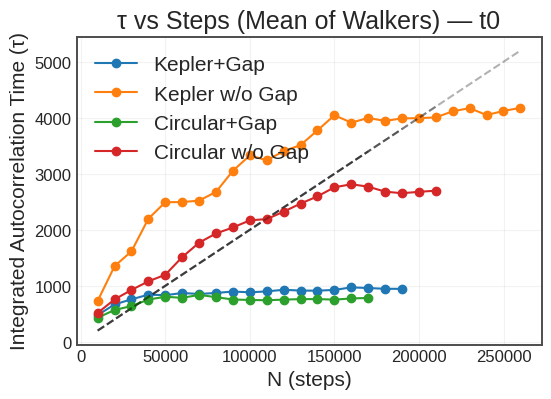

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


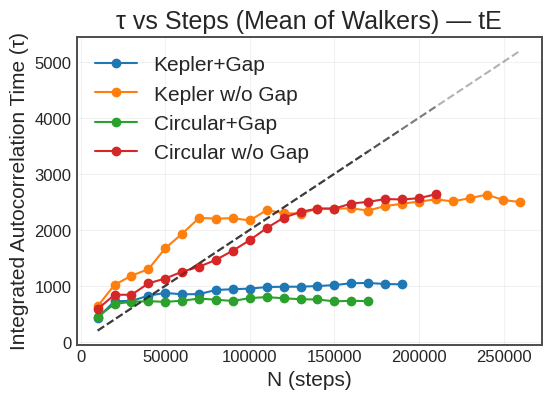

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


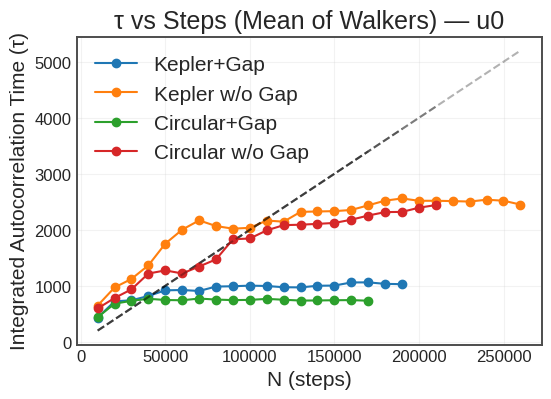

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


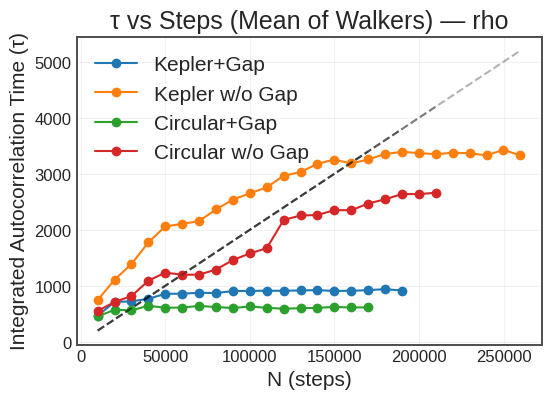

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


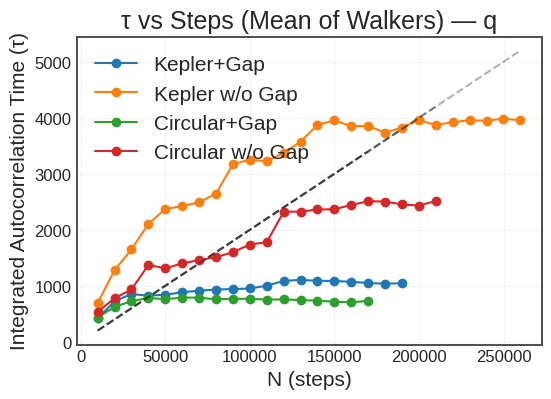

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


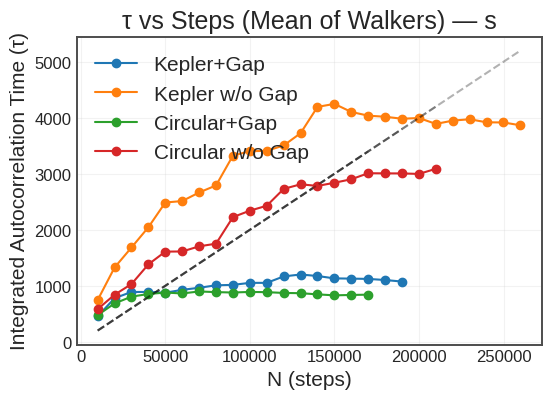

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


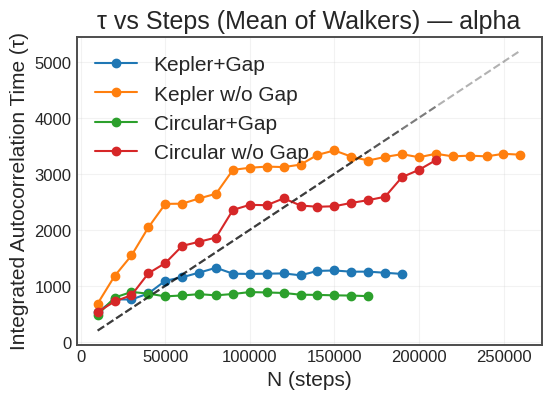

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


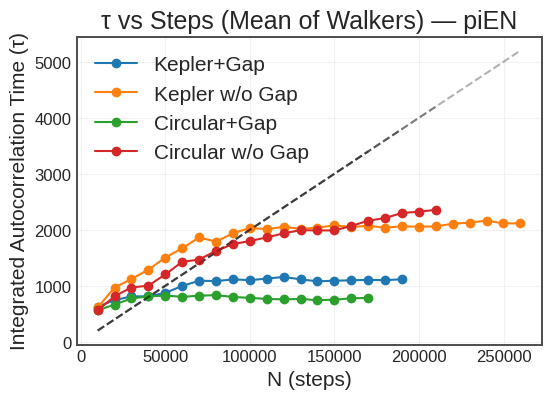

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


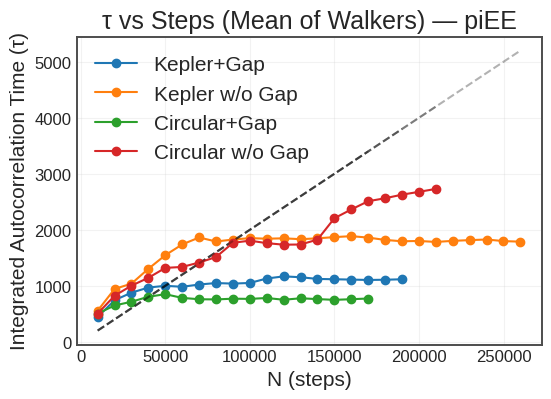

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


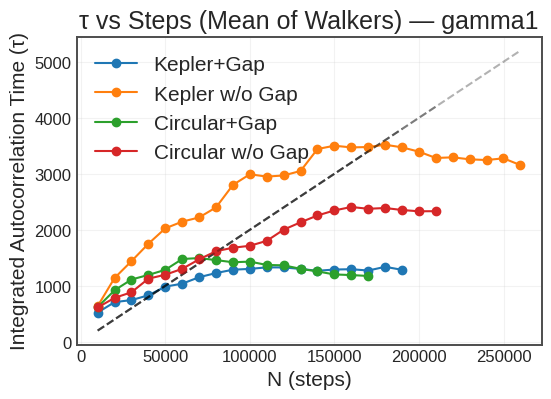

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


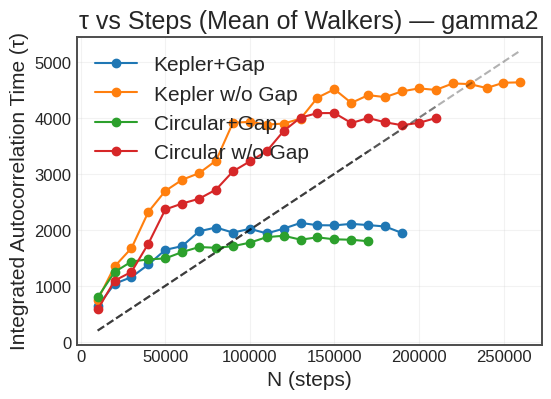

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5
../backup_important/rerun_simu_01_circular_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5


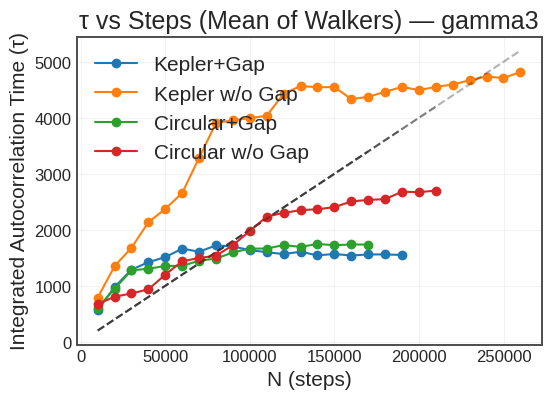

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5


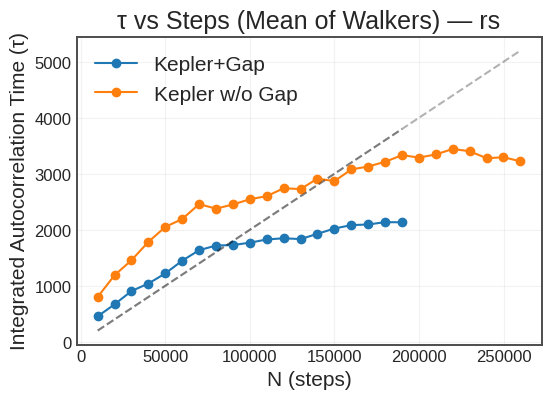

../backup_important/rerun_simu_01_kepler_chain_01.h5
../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5


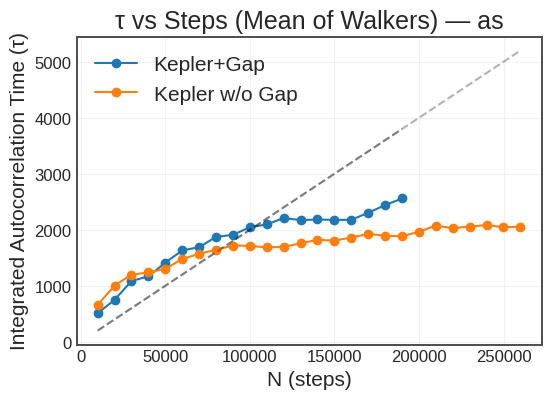

In [20]:
paths = [
    "../backup_important/rerun_simu_01_kepler_chain_01.h5",
    "../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5",
    "../backup_important/rerun_simu_01_circular_chain_01.h5",
    "../backup_important/rerun_wo_gap_simu_01_circular_chain_01.h5"
]

paths2 = [
    "../backup_important/rerun_simu_01_kepler_chain_01.h5",
    "../backup_important/rerun_wo_gap_simu_01_kepler_chain_01.h5",
]

labels = ["Kepler+Gap", "Kepler w/o Gap", "Circular+Gap", "Circular w/o Gap"]
labels2 = ["Kepler+Gap", "Kepler w/o Gap"]

ln_ths = [None, None, None, None] 

for i in range(12):
    compare_tau_param(paths, labels, param_idx=i, burnin=0, step_interval=9999,ln_prob_th_list=ln_ths)

for i in range(12,14):
    compare_tau_param(paths2, labels, param_idx=i, burnin=0, step_interval=9999)